In [77]:
import sys
!{sys.executable} -m pip install matplotlib
import os

import pandas as pd
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [78]:
# loading data
student_df = pd.read_csv("../data/processed/student_level.csv")

print(student_df.shape)
student_df.head()

(1629, 16)


,student_id,total_days,avg_engagement,engagement_variability,avg_difficulty,completion,satisfaction,learning,has_disability,disability_type,country,year,education_level,attendance_rate,early_engagement,engagement_trend
0,2024_0,12,3.533333,0.877893,2.916667,1.0,4.82,4.68,0,none,Kenya,2024,phd,0.800000,4.083333,-0.57
1,2024_10,9,3.475556,0.757663,3.000000,1.0,4.08,1.74,0,none,Peru,2024,masters,0.600000,3.323333,0.00
2,2024_1003,10,3.535000,1.102736,3.300000,1.0,3.14,4.31,0,none,Kenya,2024,phd,0.666667,4.086667,0.22
3,2024_1005,5,3.316000,0.400600,2.800000,0.0,3.26,3.11,0,none,UK,2024,undergrad,0.333333,3.350000,0.19
4,2024_1006,2,3.055000,0.671751,3.000000,0.0,1.84,4.09,1,multiple,USA,2024,masters,0.133333,3.055000,0.95


#### Overview

In [79]:
# metrics

completion_rate = student_df["completion"].mean()
avg_engagement = student_df["avg_engagement"].mean()
avg_satisfaction = student_df["satisfaction"].mean()

print(f"Completion Rate: {completion_rate:.2f}")
print(f"Avg Engagement: {avg_engagement:.2f}")
print(f"Avg Satisfaction: {avg_satisfaction:.2f}")



Completion Rate: 0.45
Avg Engagement: 3.41
Avg Satisfaction: 3.37


#### Engagement over time

In [80]:
# engagement vs completion
student_df.groupby("completion")["avg_engagement"].mean()

completion
0.0    3.403468
1.0    3.410031
Name: avg_engagement, dtype: float64

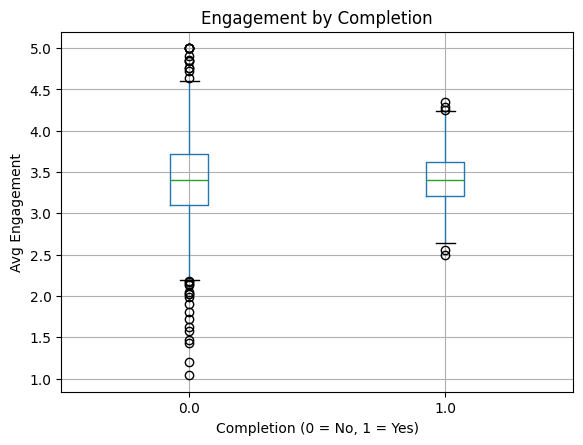

In [81]:
student_df.boxplot(column="avg_engagement", by="completion")
plt.title("Engagement by Completion")
plt.suptitle("")
plt.xlabel("Completion (0 = No, 1 = Yes)")
plt.ylabel("Avg Engagement")
plt.show()

##### Are engaged students more likely to finish the course

#### Dropout analysis

In [82]:
# attendance vs completion
student_df.groupby("completion")["attendance_rate"].mean()

completion
0.0    0.300556
1.0    0.717078
Name: attendance_rate, dtype: float64

In [83]:
# early engagement
student_df.groupby("completion")["early_engagement"].mean()

completion
0.0    3.402497
1.0    3.410123
Name: early_engagement, dtype: float64

##### We evaluate if early engagement is low → higher dropout


In [84]:
# threshold analysis 
low_engagement = student_df[student_df["early_engagement"] < 3]
high_engagement = student_df[student_df["early_engagement"] >= 3]

print("Low engagement completion:", low_engagement["completion"].mean())
print("High engagement completion:", high_engagement["completion"].mean())


Low engagement completion: 0.413265306122449
High engagement completion: 0.45917542441390463


##### eg.: Students with early engagement < 3 are significantly less likely to complete

#### Group Analysis


In [85]:
# by country 
student_df.groupby("country")["completion"].mean().sort_values()

country
Kenya      0.400844
USA        0.415888
UK         0.426778
Brazil     0.451064
Peru       0.454545
India      0.472727
Germany    0.512397
Name: completion, dtype: float64

In [86]:
student_df.columns

Index(['student_id', 'total_days', 'avg_engagement', 'engagement_variability',
       'avg_difficulty', 'completion', 'satisfaction', 'learning',
       'has_disability', 'disability_type', 'country', 'year',
       'education_level', 'attendance_rate', 'early_engagement',
       'engagement_trend'],
      dtype='str')

In [87]:
# by education level
student_df.groupby("education_level")["completion"].mean()

education_level
masters      0.469203
phd          0.448276
undergrad    0.425856
Name: completion, dtype: float64

##### Are some groups systematically disadvantaged?


#### Accessibility and disability

In [88]:
# disability vs completion
student_df.groupby("has_disability")["completion"].mean()
# student_df.groupby("has_disability")[["completion", "avg_engagement", "satisfaction"]].mean()


# By Disability Type
student_df.groupby("disability_type")["completion"].mean().sort_values()
# student_df.groupby("disability_type")[["completion", "avg_engagement"]].mean().sort_values("completion")

disability_type
prefer_not_to_say    0.355556
motor                0.393939
multiple             0.435484
none                 0.448304
visual               0.464286
cognitive            0.468354
hearing              0.511905
Name: completion, dtype: float64

In [89]:
# engagement gap in disability
student_df.groupby("has_disability")["avg_engagement"].mean()

has_disability
0    3.471100
1    3.220194
Name: avg_engagement, dtype: float64

##### Do Students with disabilities show lower engagement and completion.? if yes then suggests need for accessibility improvements

In [90]:
completion_by_group = student_df.groupby("has_disability")["completion"].mean()
equity_gap = completion_by_group.max() - completion_by_group.min()

print("Equity Gap (Disability):", equity_gap)

Equity Gap (Disability): 0.0006853361692071291


##### how unequal are outcomes?

#### Drop off patterns

In [91]:
# total days vs completion 
student_df.groupby("completion")["total_days"].mean()


completion
0.0     4.508343
1.0    10.756164
Name: total_days, dtype: float64

##### When do students drop out?


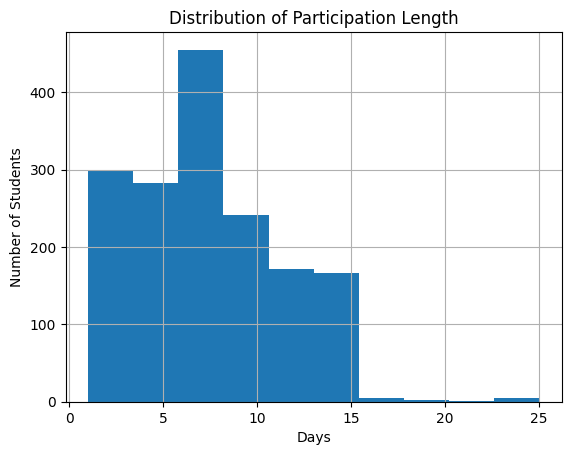

In [92]:
# histogram
student_df["total_days"].hist()
plt.title("Distribution of Participation Length")
plt.xlabel("Days")
plt.ylabel("Number of Students")
plt.show()

#### Final insights
eg 
Key Findings
	•	Students with higher early engagement are significantly more likely to complete the program
	•	Attendance rate is the strongest predictor of completion
	•	Students with disabilities show slightly lower engagement and completion rates
	•	Some countries show consistently lower completion rates

⸻

Risks
	•	Early disengagement (first 3 days) strongly predicts dropout
	•	Engagement variability suggests inconsistent experience for some students

⸻

Recommendations
	•	Introduce early engagement interventions (first 3 days)
	•	Provide additional accessibility support for students with disabilities
	•	Investigate regional differences in participation
